# 06 — Explainability with SHAP

Now that we have a winning model, we open the black box.

**Two questions answered here:**
1. *Globally*: which features does the model rely on most?
2. *Locally*: how does the model arrive at a specific prediction?

**Input:** `outputs/models/best_model.pkl` and the saved test set.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from pathlib import Path

MODELS = Path('../outputs/models')
FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")


c:\Users\jordi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Load the model and saved test set

In [ ]:
modelo_final = joblib.load(MODELS / 'xgboost_modelo_B_causal.pkl')
columnas = joblib.load(MODELS / 'X_test_columns.pkl')

X_test = pd.DataFrame(np.load(MODELS / 'X_test.npy'), columns=columnas)
y_test = np.load(MODELS / 'y_test.npy')
predicciones = np.load(MODELS / 'predictions.npy')

print(f"Model:       {type(modelo_final).__name__}")
print(f"Test shape:  {X_test.shape}")
print(f"Features:    {columnas}")


Model:       XGBRegressor
Test shape:  (1750, 25)
Features:    ['Temperatura', 'Lluvia', 'Aules_Ocupades', 'Ocupacio_Percent', 'Ocupacion_Simulada', 'Hora_del_Dia', 'Dia_Semana_Jueves', 'Dia_Semana_Lunes', 'Dia_Semana_Martes', 'Dia_Semana_Miércoles', 'Dia_Semana_Sábado', 'Dia_Semana_Viernes', 'tipus_dia_Avaluacio', 'tipus_dia_Classe', 'tipus_dia_Dissabte', 'tipus_dia_Diumenge', 'tipus_dia_Festiu', 'tipus_dia_La Benvinguda', 'tipus_dia_No lectiu', 'tipus_dia_Vacances', 'Temp_Lag_1h', 'Temp_Lag_3h', 'Delta_Temp_3h', 'ocupacion_lag_1h', 'ocupacion_lag_24h']


## 2. Classic feature importance

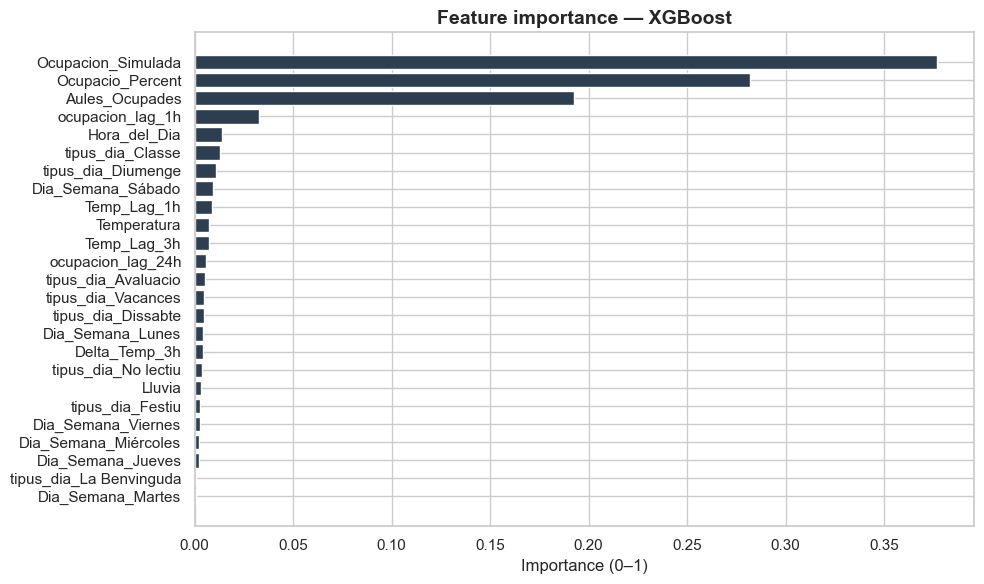

In [3]:
importancias = modelo_final.feature_importances_
indices = np.argsort(importancias)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.array(columnas)[indices], importancias[indices], color='#2c3e50')
ax.set_title("Feature importance — XGBoost", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance (0–1)")
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance.png', dpi=120)
plt.show()


## 3. Diagnostic plots: predictions vs reality, residuals

c:\Users\jordi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


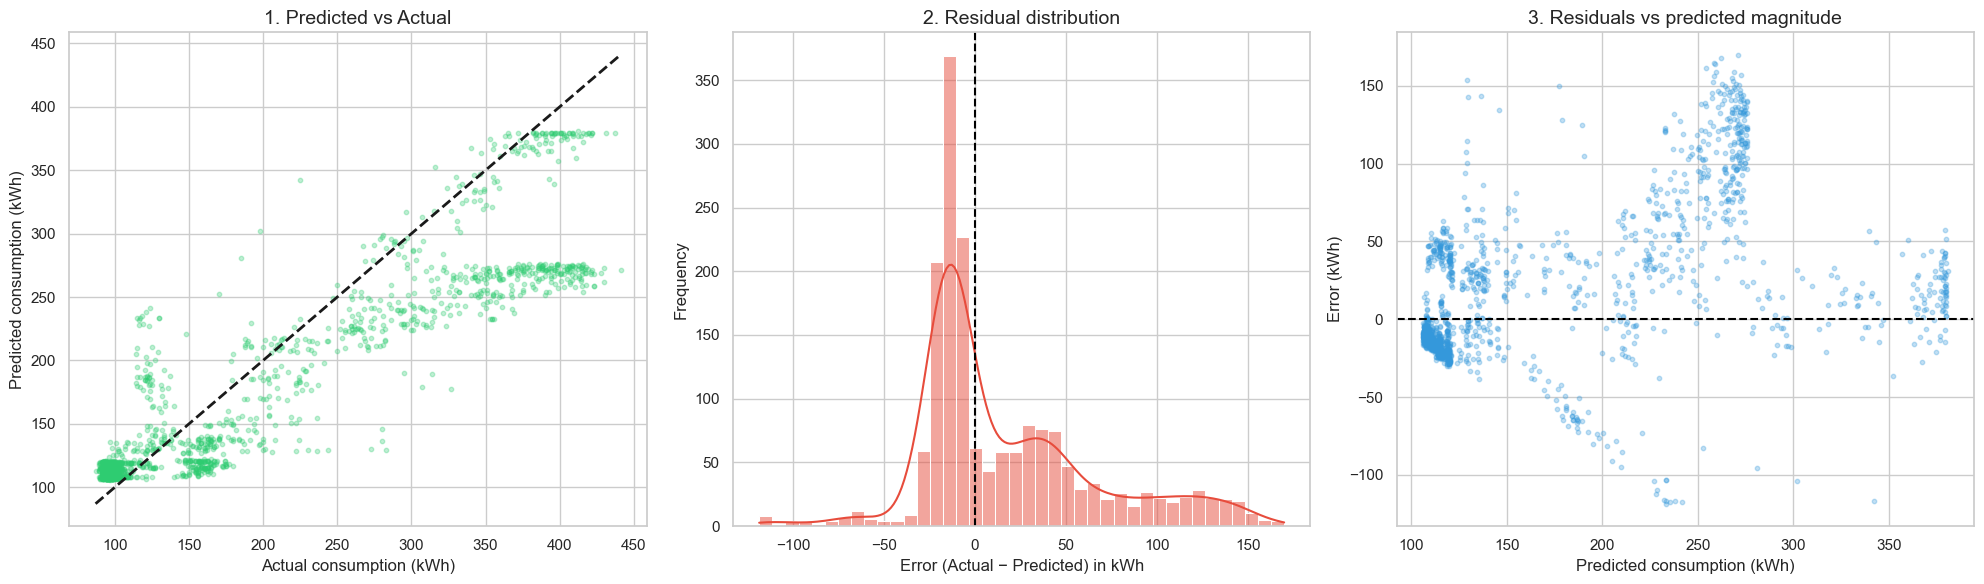

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, predicciones, alpha=0.3, color='#2ecc71', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title('1. Predicted vs Actual', fontsize=14)
axes[0].set_xlabel('Actual consumption (kWh)')
axes[0].set_ylabel('Predicted consumption (kWh)')

# Plot 2: Residuals histogram
errores = y_test - predicciones
sns.histplot(errores, bins=40, kde=True, ax=axes[1], color='#e74c3c')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('2. Residual distribution', fontsize=14)
axes[1].set_xlabel('Error (Actual − Predicted) in kWh')
axes[1].set_ylabel('Frequency')

# Plot 3: Residuals vs predicted
axes[2].scatter(predicciones, errores, alpha=0.3, color='#3498db', s=10)
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title('3. Residuals vs predicted magnitude', fontsize=14)
axes[2].set_xlabel('Predicted consumption (kWh)')
axes[2].set_ylabel('Error (kWh)')

plt.tight_layout()
plt.savefig(FIGURES / 'residual_diagnostics.png', dpi=120)
plt.show()


## 4. SHAP — global summary

Computing SHAP values (may take a few seconds)...


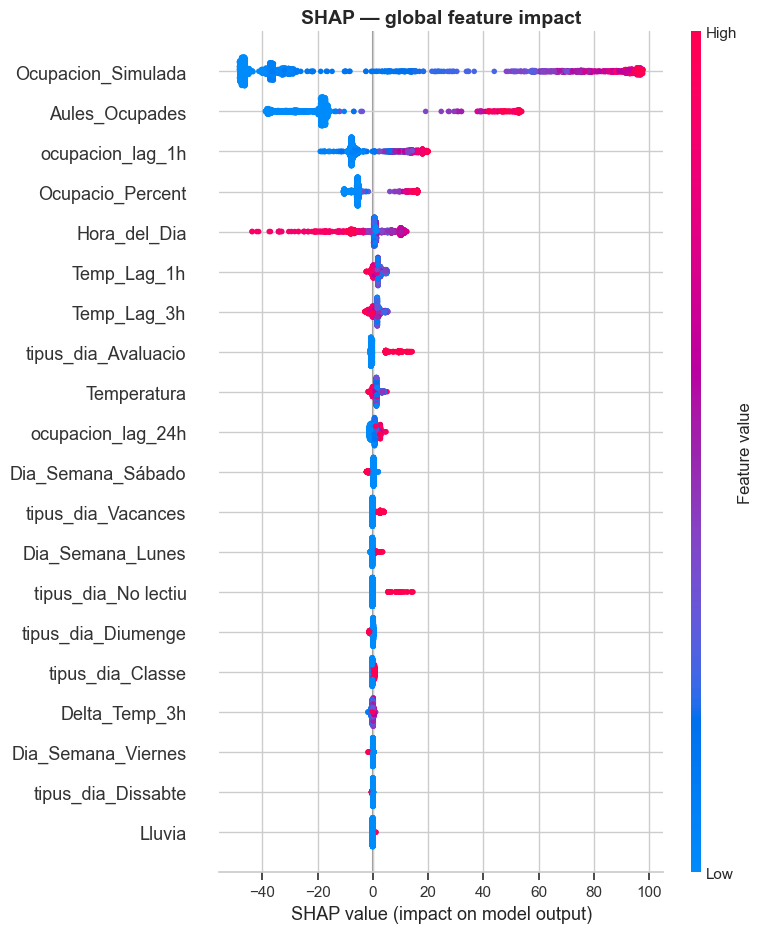

In [5]:
print("Computing SHAP values (may take a few seconds)...")
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer(X_test)

# Global summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP — global feature impact", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. SHAP — local explanation (one specific hour)

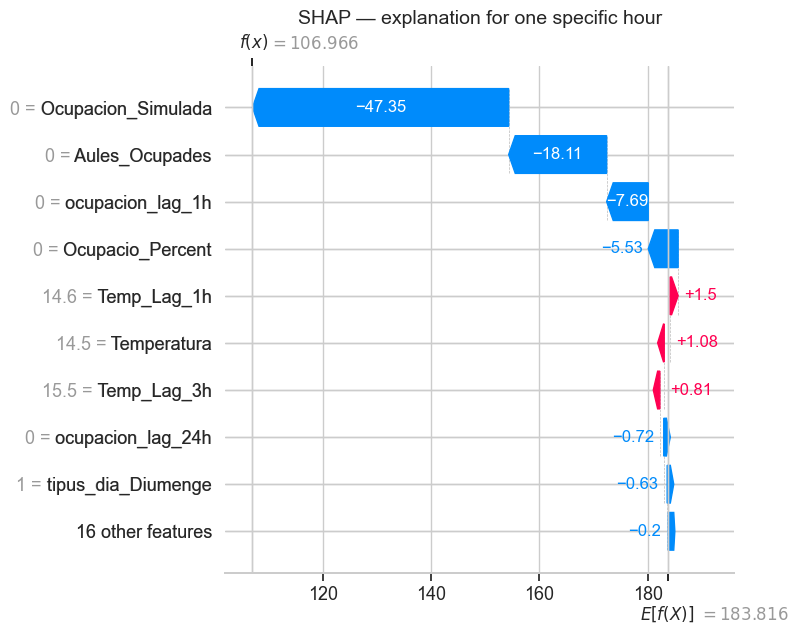

In [6]:
# Explain the very first prediction in the test set.
# You can change [0] to any other index to inspect different hours.
plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP — explanation for one specific hour", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES / 'shap_waterfall_example.png', dpi=120, bbox_inches='tight')
plt.show()
